In [12]:
import os, json
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [13]:
def read_result_file(file_path):
    with open(file_path, 'r') as f:
        results = f.readlines()

    result_dict = dict()
    k=0
    for l in results:
        l = l.strip()

        if l.startswith('baseline accuracy: '):
            baseline_acc = 1 - float(l[-6:])
            result_dict['baseline_acc'] = baseline_acc
        elif l.startswith('AutoFL-Confidence accuracy: '):
            result_dict['autofl_confidence_acc'] = float(l[-6:])
        elif l.startswith('AutoFL-Confidence roc-auc: '):
            result_dict['autofl_confidence_auc'] = float(l[-6:])
        elif l=='S':
            embedding = 'S'
            result_dict[embedding] = dict()
        elif l=='F':
            embedding = 'F'
            result_dict[embedding] = {}
        elif l=='FA':
            embedding = 'FA'
            result_dict[embedding] = {}
        elif l.startswith('k='):
            k=int(l[2:])
            result_dict[embedding][k] = {}
            # result_dict['baseline_acc'][k] = {'acc': baseline_acc}
        elif l.startswith('Best_mean_accuracy:'):
            result_dict[embedding][k]['acc'] = float(l.split()[-1])
        elif l.startswith('Best mean_roc_auc:'):
            result_dict[embedding][k]['roc_auc'] = float(l.split()[-1])
        elif l.startswith('Best mean_precision:'):
            result_dict[embedding][k]['precision'] = float(l.split()[-1])
        elif l.startswith('Best mean_recall:'):
            result_dict[embedding][k]['recall'] = float(l.split()[-1])
        elif l.startswith('Best mean_npv:'):
            result_dict[embedding][k]['npv'] = float(l.split()[-1])
        elif l.startswith('Best mean_specificity:'):
            result_dict[embedding][k]['spec'] = float(l.split()[-1])
    print(result_dict)
    return result_dict

In [14]:

def draw_graph(data, title, y_data = 'acc'):
    colors = ['b', 'g', 'r', 'c', 'm', 'y']
    labels = list(data.keys())
    x = list(data[labels[3]].keys())

    if y_data == 'acc':
        baseline_acc = data['baseline_acc']
        autofl_confidence = data['autofl_confidence_acc']
        plt.plot(x, [baseline_acc] * len(x), linestyle='-', color = colors[-2], label='baseline acc.')
        plt.plot(x, [autofl_confidence] * len(x), linestyle='-', color = colors[-1], label='autofl_confidence acc.')
    elif y_data == 'roc_auc':
        autofl_confidence_auc = data['autofl_confidence_auc']
        plt.plot(x, [autofl_confidence_auc] * len(x), linestyle='-', color = colors[-1], label='autofl_confidence auc.')

    labels.remove('baseline_acc')
    labels.remove('autofl_confidence_acc')
    labels.remove('autofl_confidence_auc')
    for i, label in enumerate(labels):
        y = []
        for k in x:
            y.append(data[label][k][y_data])
        plt.plot(x, y, linestyle='-', color=colors[i], label=label)
    
    plt.title(title)
    plt.xlabel('k')
    plt.ylabel(y_data)

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    

{'autofl_confidence_acc': 0.7246, 'autofl_confidence_auc': 0.7658, 'baseline_acc': 0.6493, 'S': {1: {'acc': 0.6493, 'roc_auc': 0.4942, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6493, 'spec': 1.0}, 2: {'acc': 0.6493, 'roc_auc': 0.4883, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6493, 'spec': 1.0}, 3: {'acc': 0.6493, 'roc_auc': 0.4469, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6493, 'spec': 1.0}, 4: {'acc': 0.6493, 'roc_auc': 0.3999, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6493, 'spec': 1.0}, 5: {'acc': 0.6493, 'roc_auc': 0.386, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6493, 'spec': 1.0}, 6: {'acc': 0.6493, 'roc_auc': 0.383, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6493, 'spec': 1.0}, 7: {'acc': 0.6493, 'roc_auc': 0.387, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6493, 'spec': 1.0}, 8: {'acc': 0.6522, 'roc_auc': 0.4376, 'precision': 0.1333, 'recall': 0.0174, 'npv': 0.6523, 'spec': 0.9957}, 9: {'acc': 0.6493, 'roc_auc': 0.384, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6493, 'spec': 1.0}

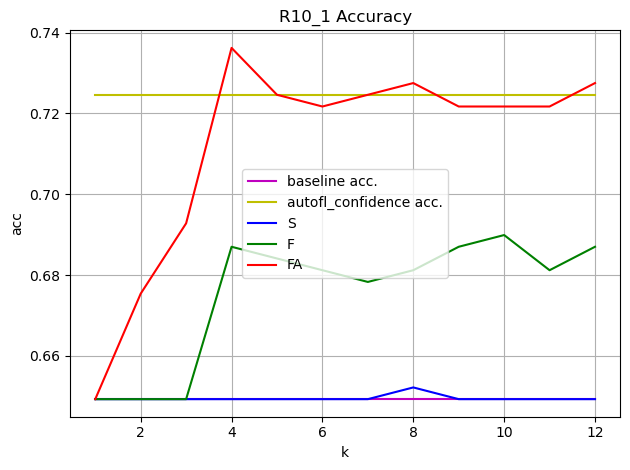

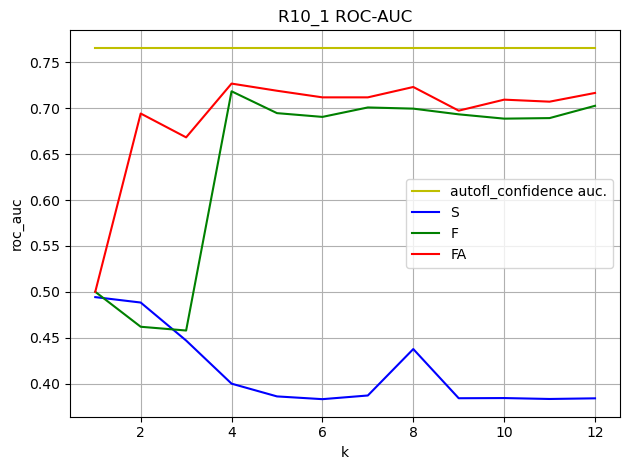

In [15]:
model = 'qwen2.5-coder'
repetition = 10
num_files = 1

result_file = f'/home/kimnal0/cosmosfl/atropos/results/one_hot/{model}/results_gcn_R{repetition}_{num_files}files.txt'

result_dict = read_result_file(result_file)
print(result_dict)

draw_graph(result_dict, f'R{repetition}_{num_files} Accuracy', 'acc')
draw_graph(result_dict, f'R{repetition}_{num_files} ROC-AUC', 'roc_auc')

{'autofl_confidence_acc': 0.742, 'autofl_confidence_auc': 0.7648, 'baseline_acc': 0.629, 'S': {1: {'acc': 0.629, 'roc_auc': 0.5, 'precision': 0.0, 'recall': 0.0, 'npv': 0.629, 'spec': 1.0}, 2: {'acc': 0.629, 'roc_auc': 0.4847, 'precision': 0.0, 'recall': 0.0, 'npv': 0.629, 'spec': 1.0}, 3: {'acc': 0.629, 'roc_auc': 0.392, 'precision': 0.0, 'recall': 0.0, 'npv': 0.629, 'spec': 1.0}, 4: {'acc': 0.629, 'roc_auc': 0.3719, 'precision': 0.0, 'recall': 0.0, 'npv': 0.629, 'spec': 1.0}, 5: {'acc': 0.629, 'roc_auc': 0.3497, 'precision': 0.0, 'recall': 0.0, 'npv': 0.629, 'spec': 1.0}, 6: {'acc': 0.629, 'roc_auc': 0.3548, 'precision': 0.0, 'recall': 0.0, 'npv': 0.629, 'spec': 1.0}, 7: {'acc': 0.629, 'roc_auc': 0.3526, 'precision': 0.0, 'recall': 0.0, 'npv': 0.629, 'spec': 1.0}, 8: {'acc': 0.629, 'roc_auc': 0.3514, 'precision': 0.0, 'recall': 0.0, 'npv': 0.629, 'spec': 1.0}, 9: {'acc': 0.629, 'roc_auc': 0.4009, 'precision': 0.0, 'recall': 0.0, 'npv': 0.629, 'spec': 1.0}, 10: {'acc': 0.629, 'roc_auc

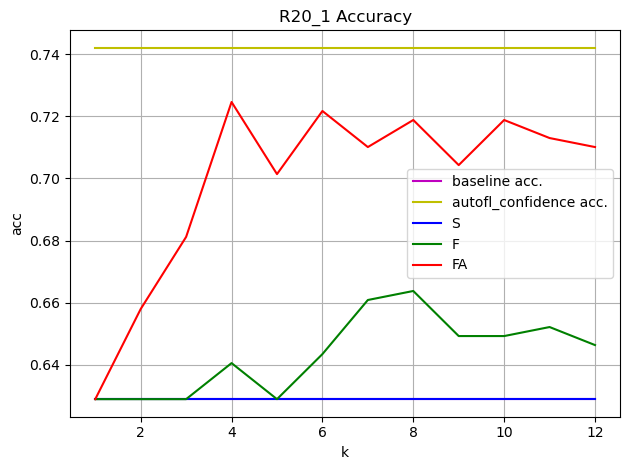

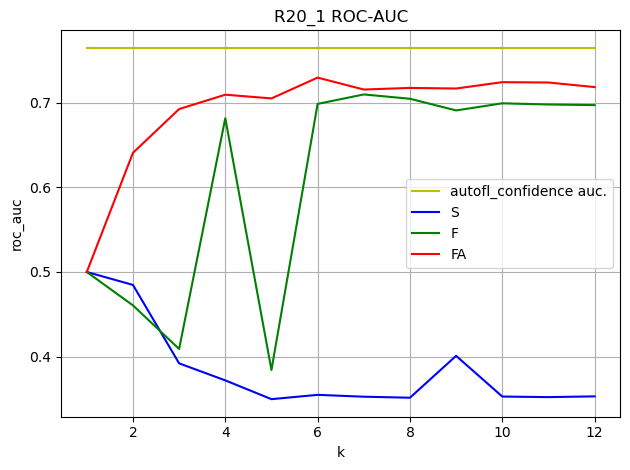

In [16]:
model = 'qwen2.5-coder'
repetition = 20
num_files = 1

result_file = f'/home/kimnal0/cosmosfl/atropos/results/one_hot/{model}/results_gcn_R{repetition}_{num_files}files.txt'

result_dict = read_result_file(result_file)
print(result_dict)

draw_graph(result_dict, f'R{repetition}_{num_files} Accuracy', 'acc')
draw_graph(result_dict, f'R{repetition}_{num_files} ROC-AUC', 'roc_auc')

{'autofl_confidence_acc': 0.7536, 'autofl_confidence_auc': 0.7926, 'baseline_acc': 0.6484, 'S': {1: {'acc': 0.6484, 'roc_auc': 0.5, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6484, 'spec': 1.0}, 2: {'acc': 0.6484, 'roc_auc': 0.5044, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6484, 'spec': 1.0}, 3: {'acc': 0.6484, 'roc_auc': 0.4213, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6484, 'spec': 1.0}, 4: {'acc': 0.6493, 'roc_auc': 0.5809, 'precision': 0.2, 'recall': 0.0023, 'npv': 0.649, 'spec': 1.0}, 5: {'acc': 0.6496, 'roc_auc': 0.5846, 'precision': 0.3333, 'recall': 0.004, 'npv': 0.6492, 'spec': 0.9996}, 6: {'acc': 0.6487, 'roc_auc': 0.5928, 'precision': 0.1333, 'recall': 0.0016, 'npv': 0.6487, 'spec': 0.9996}, 7: {'acc': 0.6496, 'roc_auc': 0.5876, 'precision': 0.3333, 'recall': 0.004, 'npv': 0.6492, 'spec': 0.9996}, 8: {'acc': 0.6487, 'roc_auc': 0.5921, 'precision': 0.1333, 'recall': 0.0016, 'npv': 0.6487, 'spec': 0.9996}, 9: {'acc': 0.6487, 'roc_auc': 0.5882, 'precision': 0.2667, 'recall': 0

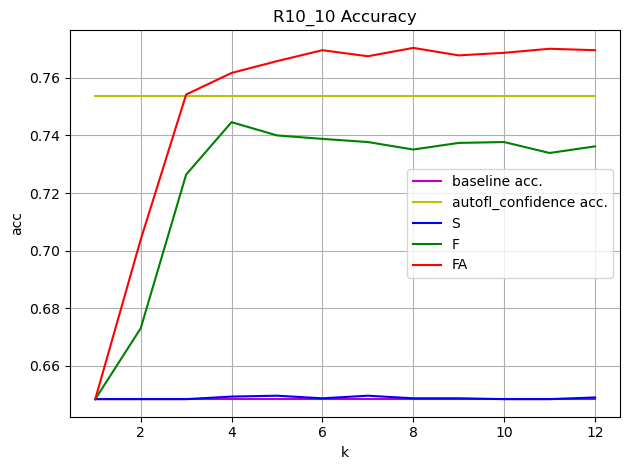

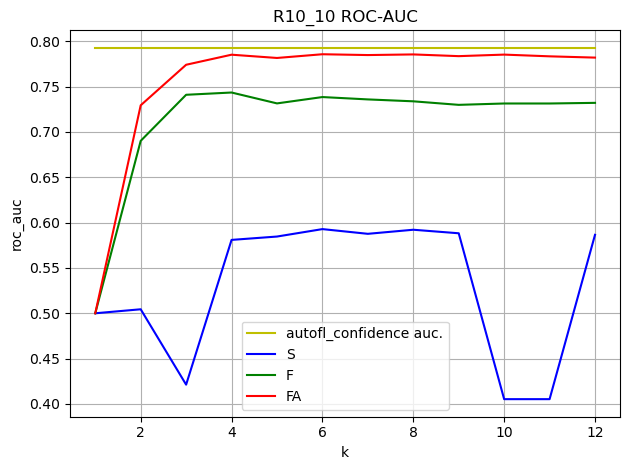

In [17]:
model = 'qwen2.5-coder'
repetition = 10
num_files = 10

result_file = f'/home/kimnal0/cosmosfl/atropos/results/one_hot/{model}/results_gcn_R{repetition}_{num_files}files.txt'

result_dict = read_result_file(result_file)
print(result_dict)

draw_graph(result_dict, f'R{repetition}_{num_files} Accuracy', 'acc')
draw_graph(result_dict, f'R{repetition}_{num_files} ROC-AUC', 'roc_auc')

{'autofl_confidence_acc': 0.7188, 'autofl_confidence_auc': 0.7676, 'baseline_acc': 0.6251, 'S': {1: {'acc': 0.6251, 'roc_auc': 0.5, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6251, 'spec': 1.0}, 2: {'acc': 0.6251, 'roc_auc': 0.4747, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6251, 'spec': 1.0}, 3: {'acc': 0.6251, 'roc_auc': 0.3918, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6251, 'spec': 1.0}, 4: {'acc': 0.6309, 'roc_auc': 0.626, 'precision': 0.6167, 'recall': 0.0227, 'npv': 0.6294, 'spec': 0.9953}, 5: {'acc': 0.6309, 'roc_auc': 0.6381, 'precision': 0.6833, 'recall': 0.0258, 'npv': 0.6298, 'spec': 0.9938}, 6: {'acc': 0.629, 'roc_auc': 0.6401, 'precision': 0.5, 'recall': 0.0201, 'npv': 0.6285, 'spec': 0.9938}, 7: {'acc': 0.6329, 'roc_auc': 0.6387, 'precision': 0.675, 'recall': 0.0497, 'npv': 0.6331, 'spec': 0.9833}, 8: {'acc': 0.63, 'roc_auc': 0.6395, 'precision': 0.65, 'recall': 0.02, 'npv': 0.6288, 'spec': 0.9953}, 9: {'acc': 0.6319, 'roc_auc': 0.6378, 'precision': 0.6327, 'recall': 0.04

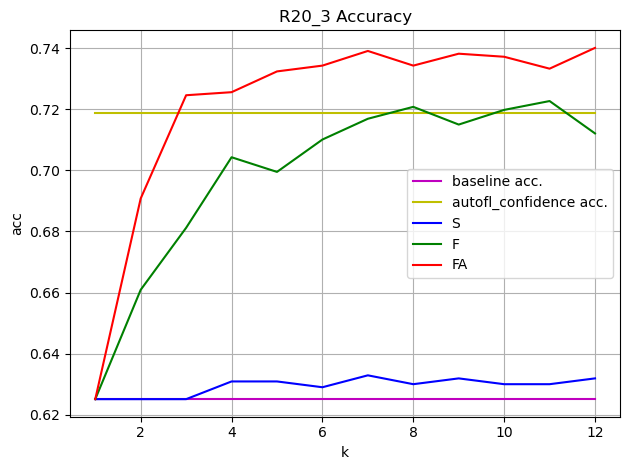

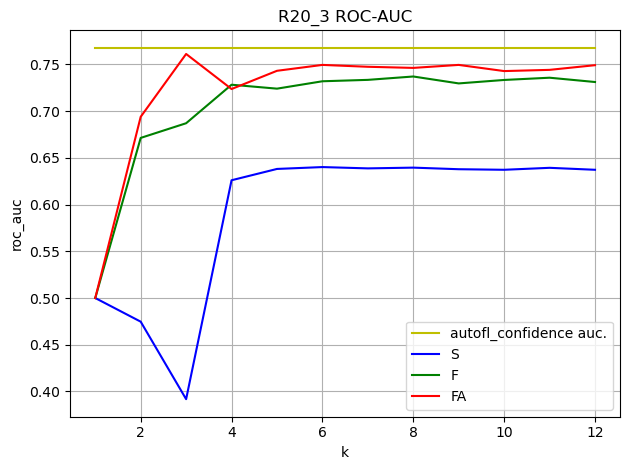

In [18]:
model = 'qwen2.5-coder'
repetition = 20
num_files = 3

result_file = f'/home/kimnal0/cosmosfl/atropos/results/one_hot/{model}/results_gcn_R{repetition}_{num_files}files.txt'

result_dict = read_result_file(result_file)
print(result_dict)

draw_graph(result_dict, f'R{repetition}_{num_files} Accuracy', 'acc')
draw_graph(result_dict, f'R{repetition}_{num_files} ROC-AUC', 'roc_auc')

{'autofl_confidence_acc': 0.7391, 'autofl_confidence_auc': 0.7651, 'baseline_acc': 0.6234999999999999, 'S': {1: {'acc': 0.6235, 'roc_auc': 0.5, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6235, 'spec': 1.0}, 2: {'acc': 0.6235, 'roc_auc': 0.476, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6235, 'spec': 1.0}, 3: {'acc': 0.6255, 'roc_auc': 0.6208, 'precision': 0.2238, 'recall': 0.009, 'npv': 0.6251, 'spec': 0.9976}, 4: {'acc': 0.6284, 'roc_auc': 0.6411, 'precision': 0.4408, 'recall': 0.0373, 'npv': 0.629, 'spec': 0.985}, 5: {'acc': 0.6336, 'roc_auc': 0.6487, 'precision': 0.585, 'recall': 0.0648, 'npv': 0.6342, 'spec': 0.9778}, 6: {'acc': 0.6345, 'roc_auc': 0.656, 'precision': 0.5406, 'recall': 0.0765, 'npv': 0.6358, 'spec': 0.9717}, 7: {'acc': 0.6394, 'roc_auc': 0.649, 'precision': 0.6107, 'recall': 0.0841, 'npv': 0.6381, 'spec': 0.9749}, 8: {'acc': 0.6336, 'roc_auc': 0.6536, 'precision': 0.5822, 'recall': 0.0742, 'npv': 0.6355, 'spec': 0.9723}, 9: {'acc': 0.6336, 'roc_auc': 0.649, 'precision

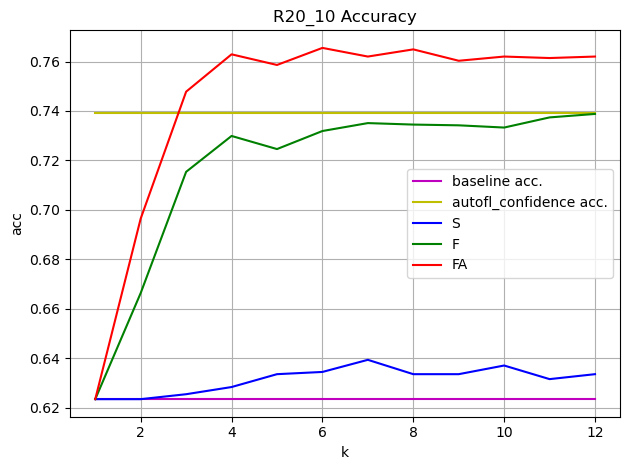

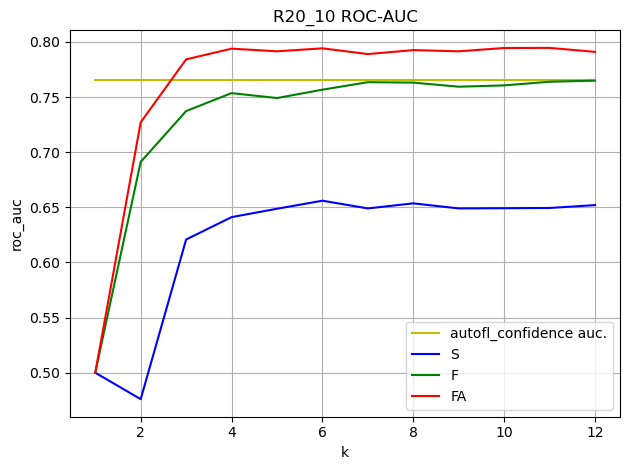

In [19]:
model = 'qwen2.5-coder'
repetition = 20
num_files = 10

result_file = f'/home/kimnal0/cosmosfl/atropos/results/one_hot/{model}/results_gcn_R{repetition}_{num_files}files.txt'

result_dict = read_result_file(result_file)
print(result_dict)

draw_graph(result_dict, f'R{repetition}_{num_files} Accuracy', 'acc')
draw_graph(result_dict, f'R{repetition}_{num_files} ROC-AUC', 'roc_auc')

{'autofl_confidence_acc': 0.7246, 'autofl_confidence_auc': 0.7658, 'baseline_acc': 0.6493, 'S': {1: {'acc': 0.6493, 'roc_auc': 0.4942, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6493, 'spec': 1.0}, 2: {'acc': 0.6493, 'roc_auc': 0.4883, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6493, 'spec': 1.0}, 3: {'acc': 0.6493, 'roc_auc': 0.4469, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6493, 'spec': 1.0}, 4: {'acc': 0.6493, 'roc_auc': 0.3999, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6493, 'spec': 1.0}, 5: {'acc': 0.6493, 'roc_auc': 0.386, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6493, 'spec': 1.0}, 6: {'acc': 0.6493, 'roc_auc': 0.383, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6493, 'spec': 1.0}, 7: {'acc': 0.6493, 'roc_auc': 0.387, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6493, 'spec': 1.0}, 8: {'acc': 0.6522, 'roc_auc': 0.4376, 'precision': 0.1333, 'recall': 0.0174, 'npv': 0.6523, 'spec': 0.9957}, 9: {'acc': 0.6493, 'roc_auc': 0.384, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6493, 'spec': 1.0}

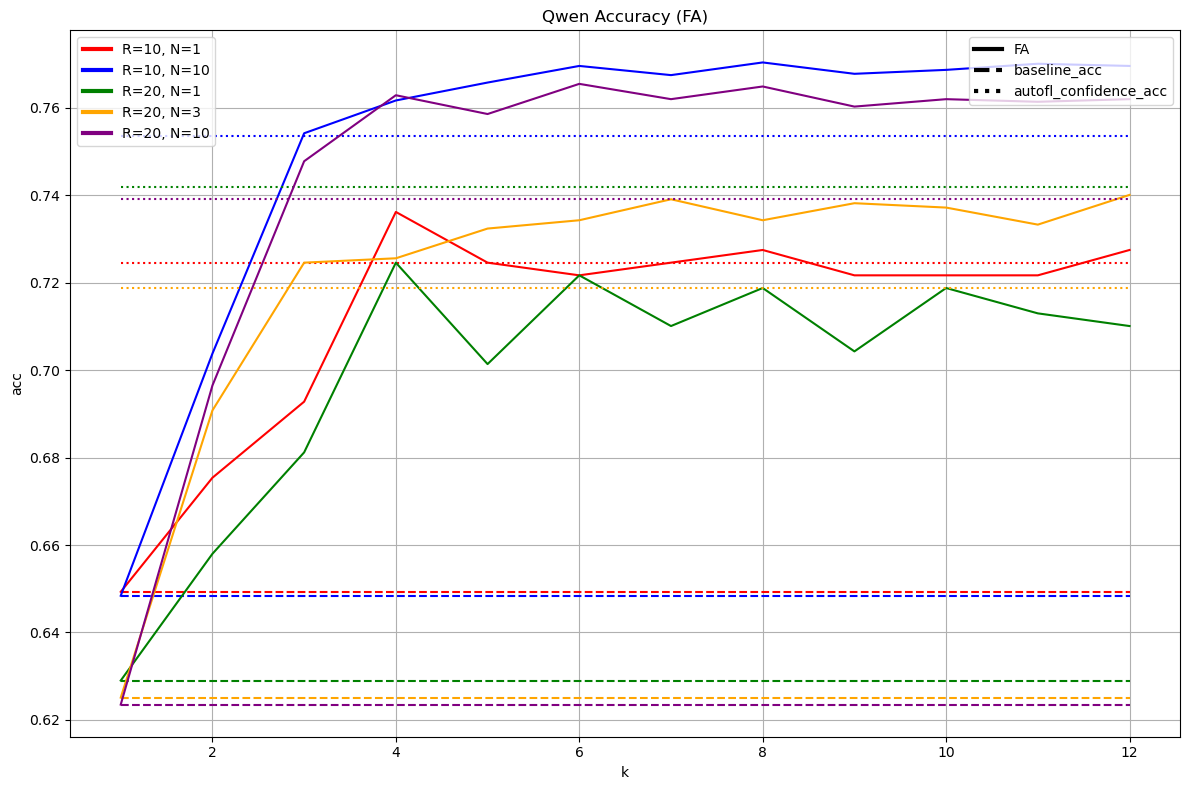

In [25]:

def draw_combination_graph(title, y_data = 'acc'):
    # base_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:yellow']
    base_colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']
    line_styles = {'FA': '-', 'baseline_acc': '--', 'autofl_confidence_acc': ':'}

    labels = {(10, 1): 'R=10, N=1', (10, 10): 'R=10, N=10', (20, 1): 'R=20, N=1', (20, 3): 'R=20, N=3', (20, 10): 'R=20, N=10'}
    # labels = {(10, 1): 'R=10, N=1', (10, 10): 'R=10, N=10'}
    x = range(1, 13)

    plt.figure(figsize=(12, 8))

    for i, ((repetition, num_files), color) in enumerate(zip(labels.keys(), base_colors)):
        result_file = f'/home/kimnal0/cosmosfl/atropos/results/one_hot/{model}/results_gcn_R{repetition}_{num_files}files.txt'

        result_dict = read_result_file(result_file)
        
        for key in ['FA']:
            y = []
            for k in x:
                y.append(result_dict[key][k][y_data])
            
            plt.plot(
                x,
                y,
                color = color,
                linestyle=line_styles[key],
                label = f"{labels[(repetition, num_files)]} - {key}"
            )
        
        # Baseline acc
        y = []
        for k in x:
            y.append(result_dict['baseline_acc'])
        
        plt.plot(
            x,
            y,
            color = color,
            linestyle=line_styles['baseline_acc'],
            # label = f"{labels[(repetition, num_files)]} - {key}"
        )

        # AutoFL-Confidence acc
        y = []
        for k in x:
            y.append(result_dict['autofl_confidence_acc'])
        
        plt.plot(
            x,
            y,
            color = color,
            linestyle=line_styles['autofl_confidence_acc'],
            # label = f"{labels[(repetition, num_files)]} - {key}"
        )
    
    
    plt.title(title)
    plt.xlabel('k')
    plt.ylabel(y_data)

    color_legend = [
        Line2D([0], [0], color=base_colors[i], lw=3, label=labels[((rep, num))]) 
        for i, (rep,num) in enumerate(labels.keys())
    ]

    first_legend = plt.legend(handles=color_legend, loc='upper left')
    plt.gca().add_artist(first_legend)

    style_legend = [
        Line2D([0], [0], color = 'black', linestyle=line_styles[key], lw=3, label=key) 
        for key in ['FA', 'baseline_acc', 'autofl_confidence_acc']
    ]
    plt.legend(handles = style_legend, loc='upper right')

    plt.grid(True)
    plt.tight_layout()
    plt.show()

draw_combination_graph("Qwen Accuracy (FA)", 'acc')
    

{'autofl_confidence_acc': 0.7246, 'autofl_confidence_auc': 0.7658, 'baseline_acc': 0.6493, 'S': {1: {'acc': 0.6493, 'roc_auc': 0.4942, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6493, 'spec': 1.0}, 2: {'acc': 0.6493, 'roc_auc': 0.4883, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6493, 'spec': 1.0}, 3: {'acc': 0.6493, 'roc_auc': 0.4469, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6493, 'spec': 1.0}, 4: {'acc': 0.6493, 'roc_auc': 0.3999, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6493, 'spec': 1.0}, 5: {'acc': 0.6493, 'roc_auc': 0.386, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6493, 'spec': 1.0}, 6: {'acc': 0.6493, 'roc_auc': 0.383, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6493, 'spec': 1.0}, 7: {'acc': 0.6493, 'roc_auc': 0.387, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6493, 'spec': 1.0}, 8: {'acc': 0.6522, 'roc_auc': 0.4376, 'precision': 0.1333, 'recall': 0.0174, 'npv': 0.6523, 'spec': 0.9957}, 9: {'acc': 0.6493, 'roc_auc': 0.384, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6493, 'spec': 1.0}

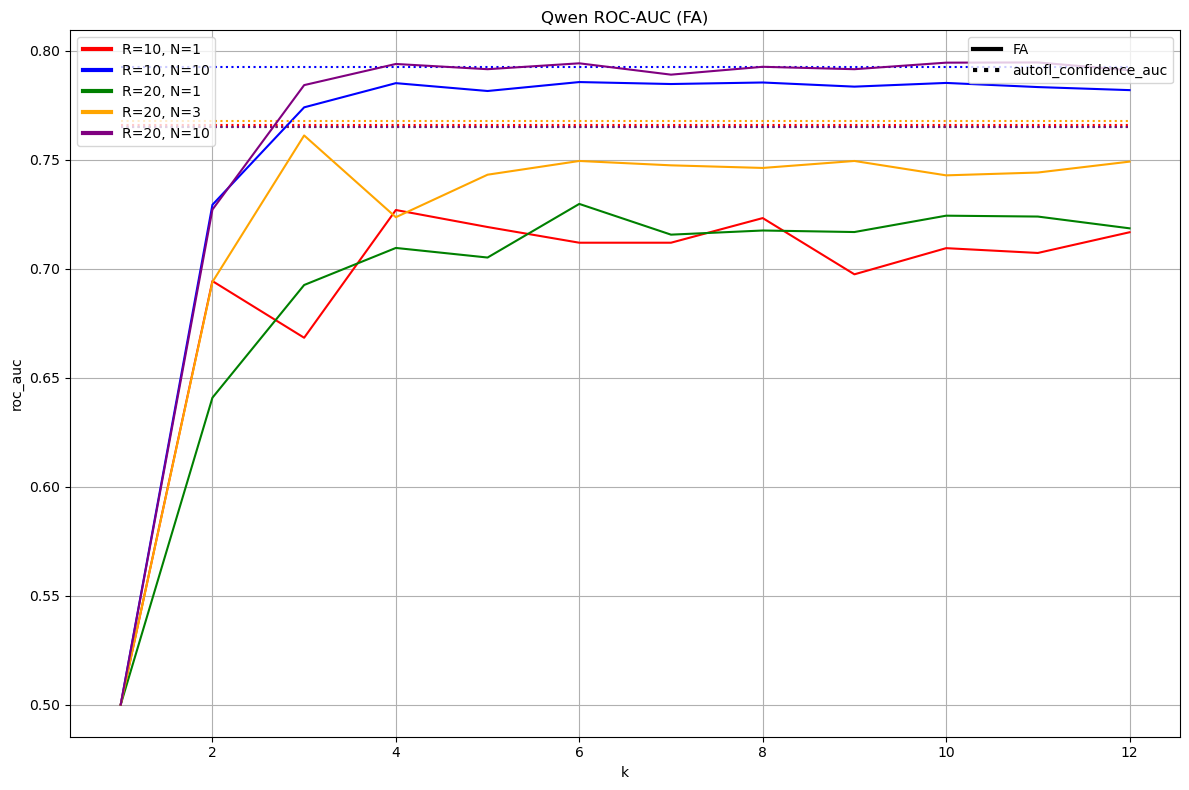

In [26]:

def draw_combination_graph(title, y_data = 'roc_auc'):
    # base_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:yellow']
    base_colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']
    line_styles = {'FA': '-', 'autofl_confidence_auc': ':'}

    labels = {(10, 1): 'R=10, N=1', (10, 10): 'R=10, N=10', (20, 1): 'R=20, N=1', (20, 3): 'R=20, N=3', (20, 10): 'R=20, N=10'}
    # labels = {(10, 1): 'R=10, N=1', (10, 10): 'R=10, N=10'}
    x = range(1, 13)

    plt.figure(figsize=(12, 8))

    for i, ((repetition, num_files), color) in enumerate(zip(labels.keys(), base_colors)):
        result_file = f'/home/kimnal0/cosmosfl/atropos/results/one_hot/{model}/results_gcn_R{repetition}_{num_files}files.txt'

        result_dict = read_result_file(result_file)
        print(result_dict)
        
        for key in ['FA']:
            y = []
            for k in x:
                y.append(result_dict[key][k][y_data])
            
            plt.plot(
                x,
                y,
                color = color,
                linestyle=line_styles[key],
                label = f"{labels[(repetition, num_files)]} - {key}"
            )
        

        # AutoFL-Confidence acc
        y = []
        for k in x:
            y.append(result_dict['autofl_confidence_auc'])
        
        plt.plot(
            x,
            y,
            color = color,
            linestyle=line_styles['autofl_confidence_auc'],
            # label = f"{labels[(repetition, num_files)]} - {key}"
        )
    
    
    plt.title(title)
    plt.xlabel('k')
    plt.ylabel(y_data)

    color_legend = [
        Line2D([0], [0], color=base_colors[i], lw=3, label=labels[((rep, num))]) 
        for i, (rep,num) in enumerate(labels.keys())
    ]

    first_legend = plt.legend(handles=color_legend, loc='upper left')
    plt.gca().add_artist(first_legend)

    style_legend = [
        Line2D([0], [0], color = 'black', linestyle=line_styles[key], lw=3, label=key) 
        for key in ['FA', 'autofl_confidence_auc']
    ]
    plt.legend(handles = style_legend, loc='upper right')

    plt.grid(True)
    plt.tight_layout()
    plt.show()

draw_combination_graph("Qwen ROC-AUC (FA)", 'roc_auc')
    

{'autofl_confidence_acc': 0.7246, 'autofl_confidence_auc': 0.7658, 'baseline_acc': 0.6493, 'S': {1: {'acc': 0.6493, 'roc_auc': 0.4942, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6493, 'spec': 1.0}, 2: {'acc': 0.6493, 'roc_auc': 0.4883, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6493, 'spec': 1.0}, 3: {'acc': 0.6493, 'roc_auc': 0.4469, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6493, 'spec': 1.0}, 4: {'acc': 0.6493, 'roc_auc': 0.3999, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6493, 'spec': 1.0}, 5: {'acc': 0.6493, 'roc_auc': 0.386, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6493, 'spec': 1.0}, 6: {'acc': 0.6493, 'roc_auc': 0.383, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6493, 'spec': 1.0}, 7: {'acc': 0.6493, 'roc_auc': 0.387, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6493, 'spec': 1.0}, 8: {'acc': 0.6522, 'roc_auc': 0.4376, 'precision': 0.1333, 'recall': 0.0174, 'npv': 0.6523, 'spec': 0.9957}, 9: {'acc': 0.6493, 'roc_auc': 0.384, 'precision': 0.0, 'recall': 0.0, 'npv': 0.6493, 'spec': 1.0}

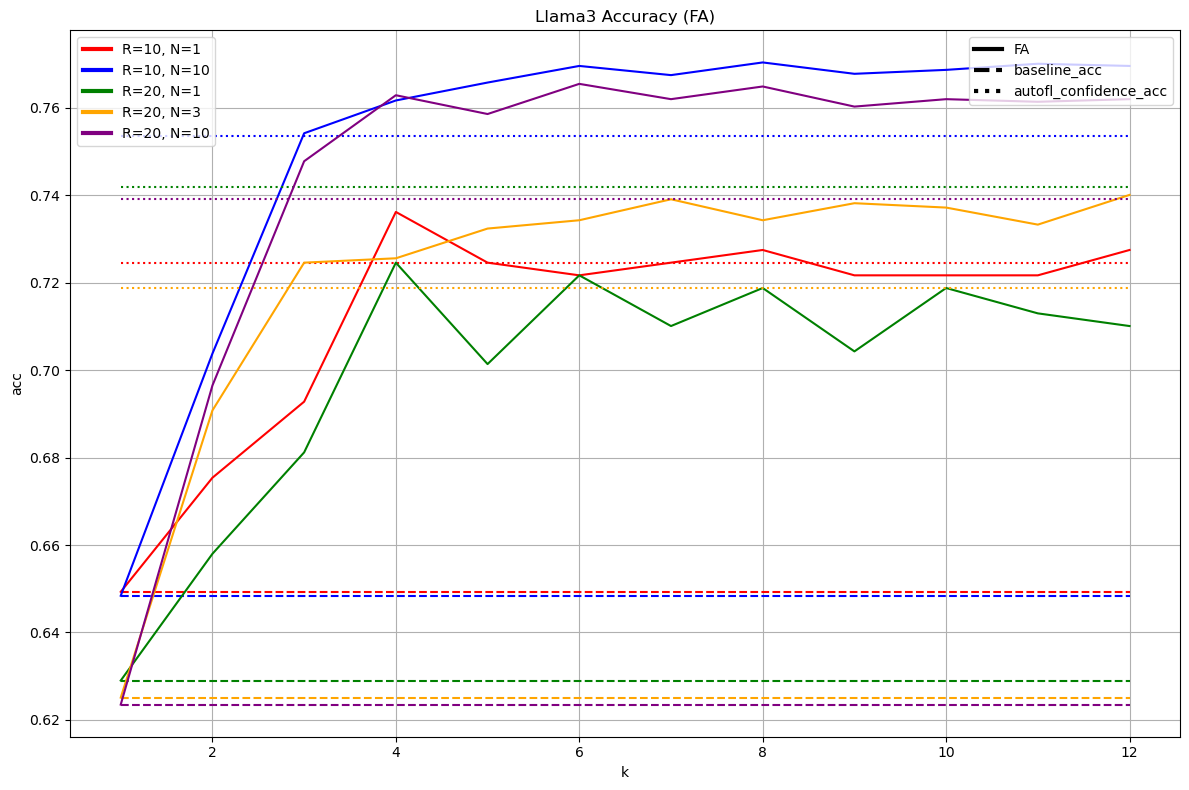

In [22]:

def draw_combination_graph(title, y_data = 'acc'):
    # base_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:yellow']
    base_colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']
    line_styles = {'FA': '-', 'baseline_acc': '--', 'autofl_confidence_acc': ':'}

    labels = {(10, 1): 'R=10, N=1', (10, 10): 'R=10, N=10', (20, 1): 'R=20, N=1', (20, 3): 'R=20, N=3', (20, 10): 'R=20, N=10'}
    # labels = {(10, 1): 'R=10, N=1', (10, 10): 'R=10, N=10'}
    x = range(1, 13)

    plt.figure(figsize=(12, 8))

    for i, ((repetition, num_files), color) in enumerate(zip(labels.keys(), base_colors)):
        result_file = f'/home/kimnal0/cosmosfl/atropos/results/one_hot/{model}/results_gcn_R{repetition}_{num_files}files.txt'

        result_dict = read_result_file(result_file)
        
        for key in ['FA']:
            y = []
            for k in x:
                y.append(result_dict[key][k][y_data])
            
            plt.plot(
                x,
                y,
                color = color,
                linestyle=line_styles[key],
                label = f"{labels[(repetition, num_files)]} - {key}"
            )
        
        # Baseline acc
        y = []
        for k in x:
            y.append(result_dict['baseline_acc'])
        
        plt.plot(
            x,
            y,
            color = color,
            linestyle=line_styles['baseline_acc'],
            # label = f"{labels[(repetition, num_files)]} - {key}"
        )

        # AutoFL-Confidence acc
        y = []
        for k in x:
            y.append(result_dict['autofl_confidence_acc'])
        
        plt.plot(
            x,
            y,
            color = color,
            linestyle=line_styles['autofl_confidence_acc'],
            # label = f"{labels[(repetition, num_files)]} - {key}"
        )
    
    
    plt.title(title)
    plt.xlabel('k')
    plt.ylabel(y_data)

    color_legend = [
        Line2D([0], [0], color=base_colors[i], lw=3, label=labels[((rep, num))]) 
        for i, (rep,num) in enumerate(labels.keys())
    ]

    first_legend = plt.legend(handles=color_legend, loc='upper left')
    plt.gca().add_artist(first_legend)

    style_legend = [
        Line2D([0], [0], color = 'black', linestyle=line_styles[key], lw=3, label=key) 
        for key in ['FA', 'baseline_acc', 'autofl_confidence_acc']
    ]
    plt.legend(handles = style_legend, loc='upper right')

    plt.grid(True)
    plt.tight_layout()
    plt.show()

draw_combination_graph("Llama3 Accuracy (FA)", 'acc')
    